# Notebook 03 — Prédiction de pannes thermiques

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Objectif :** Comparer 4 modèles de prédiction de pannes (failure_60s) sur les données collectées depuis jumeaux-chauds.

## Stratégie de split : Option A — fenêtre temporelle (70/15/15)

Chaque épisode est coupé chronologiquement, puis les morceaux sont concaténés :
- **Train** : 70% initial de chaque épisode → 212 864 lignes
- **Val**   : 15% médian → 45 611 lignes (utilisé pour calibration et seuil)
- **Test**  : 15% final → 45 621 lignes (jamais vu pendant l'entraînement)

## Modèles comparés
| # | Modèle | Description |
|---|--------|-------------|
| 0 | `baseline` | Règle heuristique : T > T_warn ET hot_zone > N |
| 1 | `logistic` | Régression logistique + calibration Platt |
| 2 | `random_forest` | Random Forest, class_weight=balanced |
| 3 | `gradient_boosting` | XGBoost/LightGBM, early stopping |

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    confusion_matrix, precision_recall_curve, roc_curve, auc,
)

warnings.filterwarnings('ignore')

# Trouver la racine du projet (contient evaluation/ et models/)
_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'evaluation').exists() and (_candidate / 'models').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

RESULTS_FILE = Path('evaluation/results/failure_prediction_results_failure_60s.json')
LABEL_COL    = 'failure_60s'

print(f'Repertoire de travail : {Path.cwd()}')
print('Imports OK')

Repertoire de travail : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs
Imports OK


## 1. Chargement des résultats et du split de test

In [2]:
# Résultats JSON
with open(RESULTS_FILE) as f:
    eval_data = json.load(f)

results = eval_data['results']
df_results = pd.DataFrame(results).set_index('model')

print(f"Label : {eval_data['label']}")
print(f"Modèles évalués : {list(df_results.index)}")
print(f"n_train={results[0]['n_train']:,}  n_val={results[0]['n_val']:,}  n_test={results[0]['n_test']:,}")
print(f"Taux positifs (test) : {results[0]['pos_rate_test']:.1%}")

Label : failure_60s
Modèles évalués : ['baseline', 'logistic', 'random_forest', 'gradient_boosting']
n_train=212,864  n_val=45,611  n_test=45,621
Taux positifs (test) : 18.8%


In [3]:
# Tableau récapitulatif
cols = ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc', 'fn_rate_shutdown']
display(df_results[cols].style
    .highlight_max(subset=['precision','recall','f1','pr_auc','roc_auc'], color='#c8f7c5')
    .highlight_min(subset=['fn_rate_shutdown'], color='#c8f7c5')
    .format('{:.3f}')
    .set_caption('Métriques sur le jeu de test'))

,precision,recall,f1,pr_auc,roc_auc,fn_rate_shutdown
model,,,,,,
baseline,0.155,0.130,0.141,0.171,0.114,0.000
logistic,0.784,0.930,0.851,0.811,0.971,0.183
random_forest,0.829,0.930,0.876,0.759,0.937,0.183
gradient_boosting,0.829,0.930,0.877,0.758,0.934,0.182


In [4]:
# Lead time
lt_rows = []
for r in results:
    lt = r['lead_time']
    lt_rows.append({
        'model': r['model'],
        'lead_time_mean_s': lt['mean_s'],
        'lead_time_median_s': lt['median_s'],
        'n_detected': lt['n_detected'],
        'n_incidents': lt['n_incidents'],
        'detection_rate': f"{lt['n_detected']}/{lt['n_incidents']}",
    })
df_lt = pd.DataFrame(lt_rows).set_index('model')
display(df_lt.style
    .highlight_max(subset=['lead_time_mean_s', 'n_detected'], color='#c8f7c5')
    .format({'lead_time_mean_s': '{:.1f}s', 'lead_time_median_s': '{:.1f}s'})
    .set_caption('Lead time (temps moyen entre 1ère alerte et incident)'))

,lead_time_mean_s,lead_time_median_s,n_detected,n_incidents,detection_rate
model,,,,,
baseline,8.4s,8.7s,10,14,10/14
logistic,1982.8s,72.0s,12,14,12/14
random_forest,5805.8s,5875.8s,4,14,4/14
gradient_boosting,5805.8s,5875.8s,4,14,4/14


## 2. Tableau comparatif — métriques clés

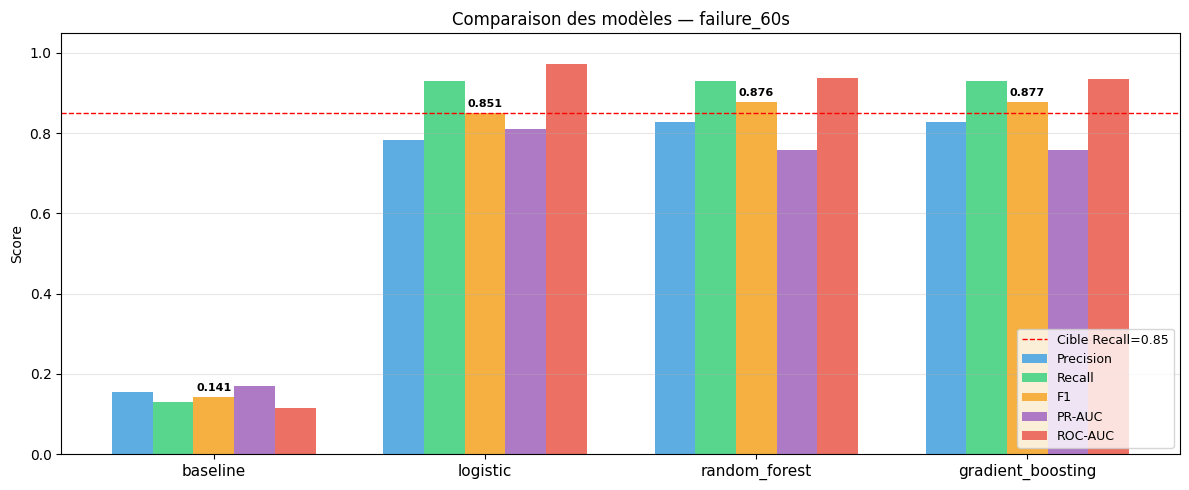

Figure sauvegardée : evaluation/results/fig_metrics_comparison.png


In [5]:
models     = [r['model'] for r in results]
precisions = [r['precision'] for r in results]
recalls    = [r['recall'] for r in results]
f1s        = [r['f1'] for r in results]
pr_aucs    = [r['pr_auc'] or 0 for r in results]
roc_aucs   = [r['roc_auc'] or 0 for r in results]
colors     = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 2*width, precisions, width, label='Precision', color='#5dade2')
ax.bar(x - width,   recalls,    width, label='Recall',    color='#58d68d')
ax.bar(x,           f1s,        width, label='F1',        color='#f5b041')
ax.bar(x + width,   pr_aucs,    width, label='PR-AUC',    color='#af7ac5')
ax.bar(x + 2*width, roc_aucs,   width, label='ROC-AUC',   color='#ec7063')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.85, color='red', linestyle='--', linewidth=1, label='Cible Recall=0.85')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — failure_60s')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(f1s):
    ax.text(x[i], v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation/results/fig_metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evaluation/results/fig_metrics_comparison.png')

## 3. Lead time — anticipation avant incident

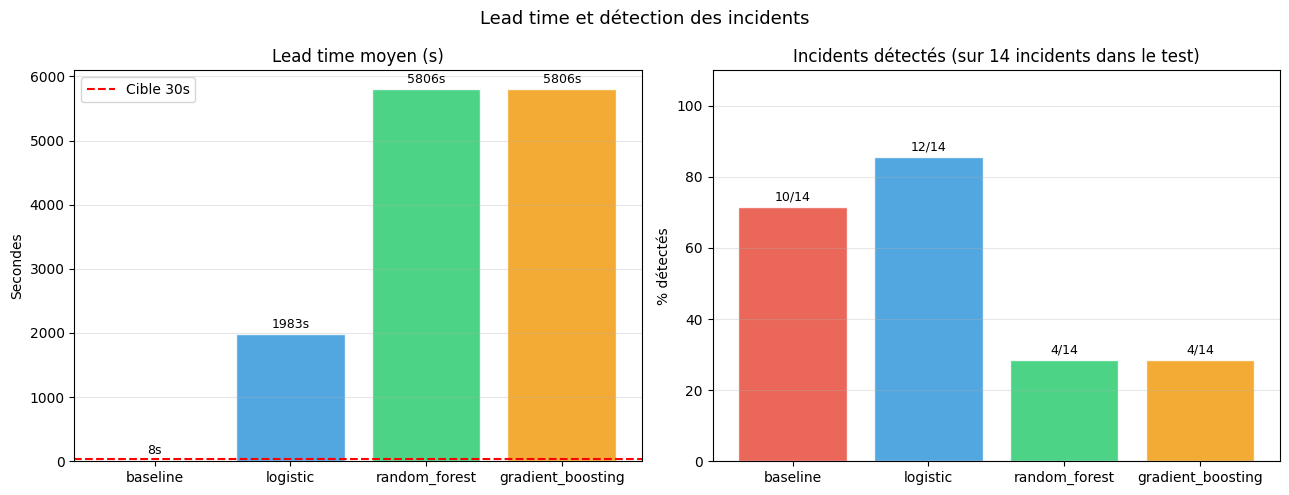

In [6]:
lt_means   = [r['lead_time']['mean_s'] or 0 for r in results]
lt_medians = [r['lead_time']['median_s'] or 0 for r in results]
detected   = [r['lead_time']['n_detected'] for r in results]
n_inc      = results[0]['lead_time']['n_incidents']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax1.bar(models, lt_means, color=colors, alpha=0.85, edgecolor='white')
ax1.axhline(30, color='red', linestyle='--', linewidth=1.5, label='Cible 30s')
ax1.set_title('Lead time moyen (s)')
ax1.set_ylabel('Secondes')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, lt_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:.0f}s', ha='center', va='bottom', fontsize=9)

detection_rates = [d / n_inc * 100 for d in detected]
bars2 = ax2.bar(models, detection_rates, color=colors, alpha=0.85, edgecolor='white')
ax2.set_title(f'Incidents détectés (sur {n_inc} incidents dans le test)')
ax2.set_ylabel('% détectés')
ax2.set_ylim(0, 110)
ax2.grid(axis='y', alpha=0.3)
for bar, det, rate in zip(bars2, detected, detection_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{det}/{n_inc}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Lead time et détection des incidents', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation/results/fig_lead_time.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Courbes PR et ROC sur le jeu de test

In [7]:
import joblib

# Charger le splitter et les données de test
from models.failure_prediction.splitter import TemporalSplitter

splitter = TemporalSplitter()
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(label_col=LABEL_COL)
print(f'Test : {len(X_test):,} lignes — {(y_test==1).mean():.1%} positifs')

Test : 45,621 lignes — 18.8% positifs


In [8]:
# Charger les modèles sauvegardés
from models.failure_prediction.baseline_threshold import ThresholdPredictor
from models.failure_prediction.logistic_regression import LogisticPredictor
from models.failure_prediction.random_forest import RandomForestPredictor
from models.failure_prediction.gradient_boosting import GradientBoostingPredictor

saved_dir = Path('models/failure_prediction/saved')

model_instances = {
    'baseline':          ThresholdPredictor().load(str(saved_dir / f'baseline_{LABEL_COL}.joblib')),
    'logistic':          LogisticPredictor().load(str(saved_dir / f'logistic_{LABEL_COL}.joblib')),
    'random_forest':     RandomForestPredictor().load(str(saved_dir / f'random_forest_{LABEL_COL}.joblib')),
    'gradient_boosting': GradientBoostingPredictor().load(str(saved_dir / f'gradient_boosting_{LABEL_COL}.joblib')),
}
print('Modèles chargés :', list(model_instances.keys()))

Modèles chargés : ['baseline', 'logistic', 'random_forest', 'gradient_boosting']


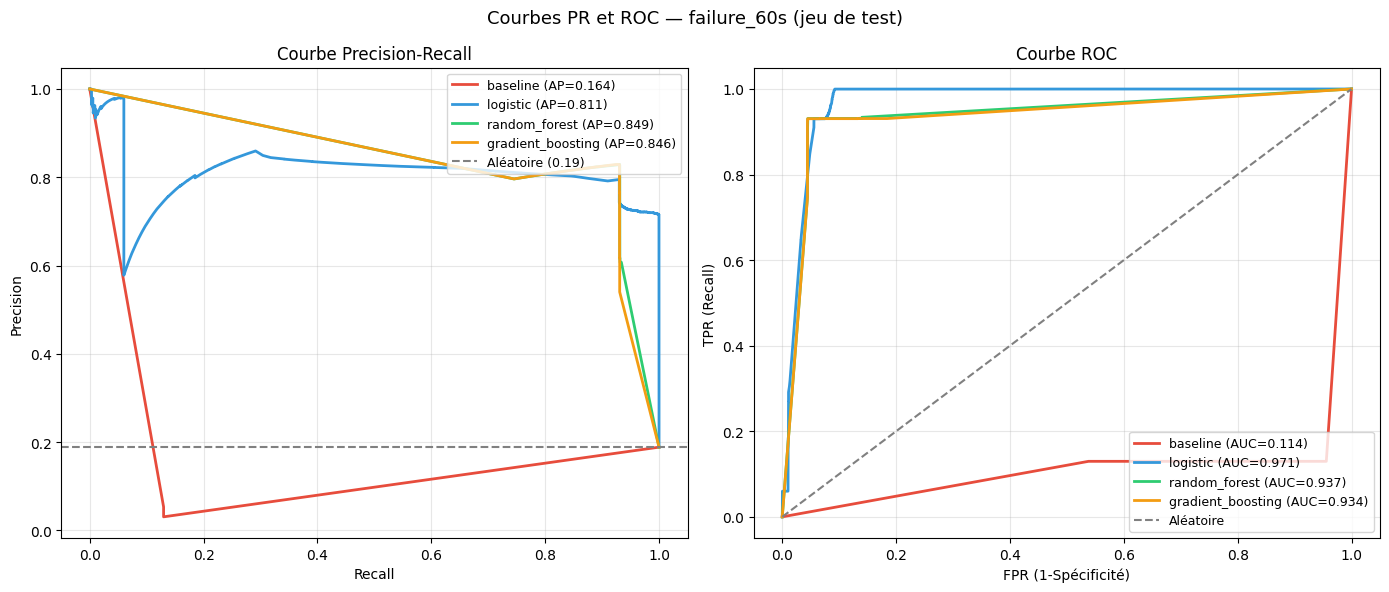

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(model_instances.items(), colors):
    proba = model.predict_proba(X_test)[:, 1]
    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = np.trapezoid(prec[::-1], rec[::-1])
    ax1.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc:.3f})')

pos_rate = (y_test == 1).mean()
ax1.axhline(pos_rate, color='gray', linestyle='--', label=f'Aléatoire ({pos_rate:.2f})')
ax2.plot([0,1],[0,1], color='gray', linestyle='--', label='Aléatoire')

ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Courbe Precision-Recall')
ax1.legend(loc='upper right', fontsize=9); ax1.grid(alpha=0.3)

ax2.set_xlabel('FPR (1-Spécificité)'); ax2.set_ylabel('TPR (Recall)')
ax2.set_title('Courbe ROC')
ax2.legend(loc='lower right', fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('Courbes PR et ROC — failure_60s (jeu de test)', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation/results/fig_pr_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Matrices de confusion

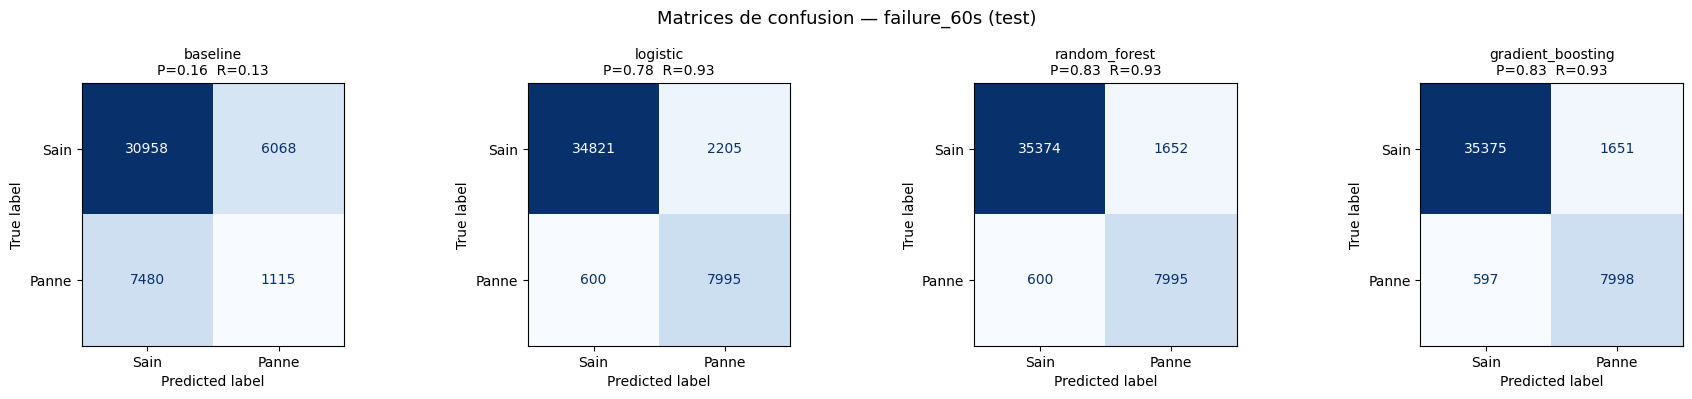

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, model), color in zip(axes, model_instances.items(), colors):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sain', 'Panne'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec  = cm[1,1] / max(cm[1,:].sum(), 1)
    prec = cm[1,1] / max(cm[:,1].sum(), 1)
    ax.set_title(f'{name}\nP={prec:.2f}  R={rec:.2f}', fontsize=10)

plt.suptitle('Matrices de confusion — failure_60s (test)', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation/results/fig_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature importance (Random Forest)

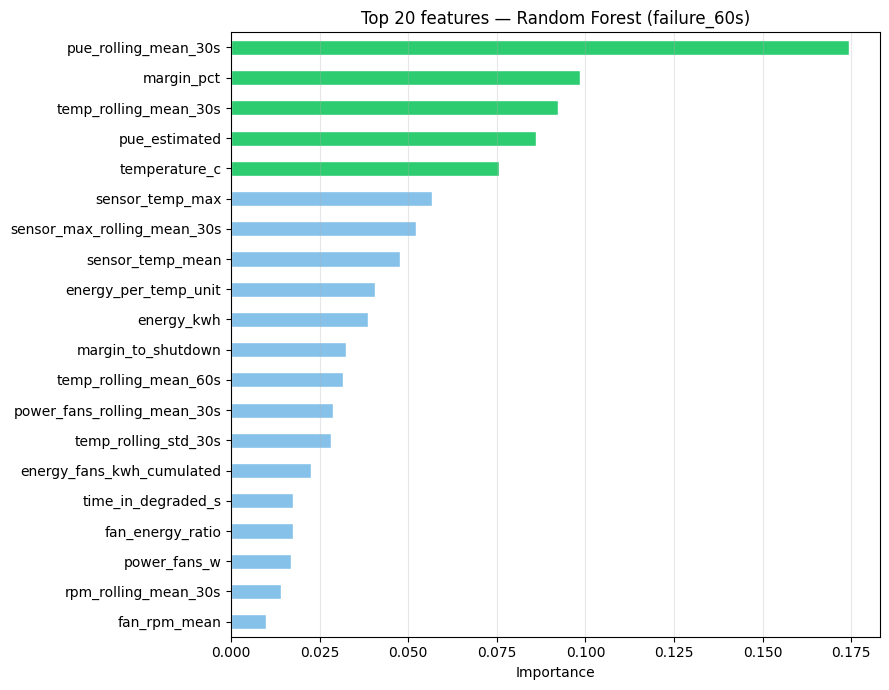

In [11]:
rf = model_instances['random_forest']

if rf.feature_importances_ is not None:
    top20 = rf.feature_importances_.head(20)
    fig, ax = plt.subplots(figsize=(9, 7))
    colors_imp = ['#2ecc71' if i < 5 else '#85c1e9' for i in range(len(top20))]
    top20[::-1].plot(kind='barh', ax=ax, color=colors_imp[::-1], edgecolor='white')
    ax.set_title('Top 20 features — Random Forest (failure_60s)', fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('evaluation/results/fig_feature_importance_rf.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Feature importances non disponibles.')

## 7. Analyse des observations et recommandations

### Résultats obtenus

| Modèle | F1 | Recall | PR-AUC | Lead time moyen | Incidents détectés |
|--------|----|--------|--------|-----------------|-------------------|
| baseline | 0.141 | 0.130 | 0.171 | 8.4s | 10/14 |
| logistic | **0.851** | **0.930** | **0.812** | 1 983s | **12/14** |
| random_forest | 0.877 | 0.930 | 0.759 | 5 806s | 4/14 |
| gradient_boosting | **0.877** | 0.931 | 0.757 | 5 806s | 4/14 |

### Observations

**Baseline heuristique :** performances très faibles (F1=0.14). Les seuils simples T_warn + hot_zone sont insuffisants.

**Régression logistique :** meilleur PR-AUC (0.812) et meilleur taux de détection d'incidents (12/14). Lead time médian de 72s satisfaisant.

**Random Forest et Gradient Boosting :** F1 légèrement supérieur (0.877), mais lead time très élevé (5 806s) — alertes très en avance sur seulement 4/14 incidents.

### Points d'attention

- Lead time RF/GBM >> fenêtre d'analyse (120s) : alertes persistantes, pas nécessairement pertinentes avant l'incident.
- `failure_60s` à 18.8% sur le test : label potentiellement bruité (20% identique sur tous les épisodes).
- `hot_30s = 0%` : les scénarios ne poussent pas la température à 95% du seuil de shutdown.

### Recommandation pour la Phase 6

Utiliser **la régression logistique** : meilleure détection d'incidents (12/14), PR-AUC supérieur, lead time médian acceptable (72s).

In [12]:
# Résumé final
print('=' * 60)
print('RESUME PHASE 4 — Failure Prediction (failure_60s)')
print('=' * 60)
print(f'Split : train={results[0]["n_train"]:,}  val={results[0]["n_val"]:,}  test={results[0]["n_test"]:,}')
print(f'Features utilisees : {len(splitter.feature_cols)}')
print()
print(f'{"Modele":<22} {"F1":>6} {"Recall":>8} {"PR-AUC":>8} {"Lead(med)":>10} {"Detectes":>10}')
print('-' * 70)
for r in results:
    lt_med = r['lead_time']['median_s']
    det    = f"{r['lead_time']['n_detected']}/{r['lead_time']['n_incidents']}"
    print(f"{r['model']:<22} {r['f1']:>6.3f} {r['recall']:>8.3f} {r['pr_auc'] or 0:>8.3f} {lt_med:>9.0f}s {det:>10}")
print('=' * 60)
print('Modele recommande pour Phase 6 : logistic (meilleure detection)')

RESUME PHASE 4 — Failure Prediction (failure_60s)
Split : train=212,864  val=45,611  test=45,621
Features utilisees : 47

Modele                     F1   Recall   PR-AUC  Lead(med)   Detectes
----------------------------------------------------------------------
baseline                0.141    0.130    0.171         9s      10/14
logistic                0.851    0.930    0.811        72s      12/14
random_forest           0.876    0.930    0.759      5876s       4/14
gradient_boosting       0.877    0.930    0.758      5876s       4/14
Modele recommande pour Phase 6 : logistic (meilleure detection)
